# Steel Defect Detection - Model Comparison and Analysis

This analysis includes:

- Overall Dice performance
- Per-class Dice (C1–C4)
- Model efficiency (epochs trained)
- Class-wise learning behavior
- Trade-offs and model rankings

### Modules

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': 'Times New Roman'})
plt.rcParams.update({'font.size': 14})

### Load CSV

In [15]:
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
RESULTS_FILE = os.path.join(ROOT_DIR, "Results", "model_results_steel.csv")
print("Results file path:", RESULTS_FILE)

Results file path: e:\Studies\MIT\8\Project\Results\model_results_steel.csv


In [16]:
df = pd.read_csv(RESULTS_FILE)

print("Loaded Results:\n")
df

Loaded Results:



,model_name,best_val_dice,dice_c1,dice_c2,dice_c3,dice_c4,epochs_trained
0,convnext_tiny,0.80895,0.87466,0.96330,0.46297,0.93487,29
1,mit_b3,0.74510,0.86200,0.95200,0.39512,0.77126,8
2,resnet50,0.72961,0.60515,0.96150,0.48463,0.86715,11
3,swin_base_patch4_window7_224,0.79987,0.84627,0.95385,0.46311,0.93625,21
4,timm-efficientnet-b4,0.76582,0.68811,0.96100,0.50174,0.91242,15
5,vit_base_patch16_224,0.79555,0.83281,0.94987,0.48499,0.91454,37
6,mit_b4,0.88838,0.92365,0.98581,0.71095,0.93312,50


### Ranked Comparison Table

In [17]:
df_sorted = df.sort_values(by="best_val_dice", ascending=False)
df_sorted

,model_name,best_val_dice,dice_c1,dice_c2,dice_c3,dice_c4,epochs_trained
6,mit_b4,0.88838,0.92365,0.98581,0.71095,0.93312,50
0,convnext_tiny,0.80895,0.87466,0.96330,0.46297,0.93487,29
3,swin_base_patch4_window7_224,0.79987,0.84627,0.95385,0.46311,0.93625,21
5,vit_base_patch16_224,0.79555,0.83281,0.94987,0.48499,0.91454,37
4,timm-efficientnet-b4,0.76582,0.68811,0.96100,0.50174,0.91242,15
1,mit_b3,0.74510,0.86200,0.95200,0.39512,0.77126,8
2,resnet50,0.72961,0.60515,0.96150,0.48463,0.86715,11


### Overall Dice Comparison

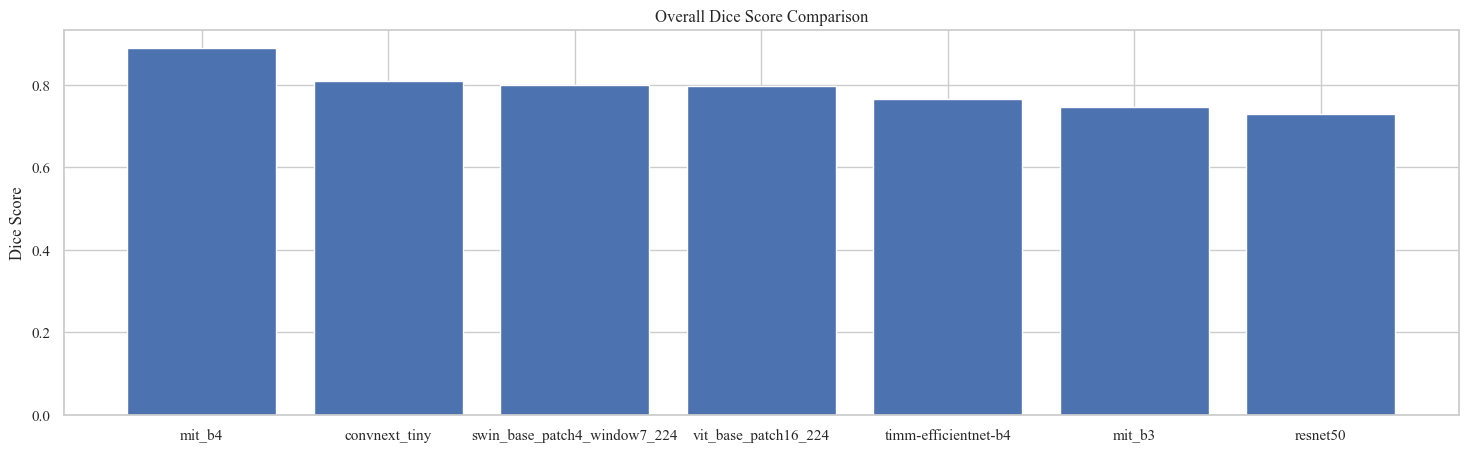

In [18]:
plt.figure(figsize=(18,5))

plt.bar(df_sorted["model_name"], df_sorted["best_val_dice"])
# plt.xticks(rotation=45)
plt.ylabel("Dice Score")
plt.title("Overall Dice Score Comparison")

plt.show()

### Per Class Dice Score Comparison

Evaluating how each model performs across:

- Class 1 (C1)
- Class 2 (C2)
- Class 3 (C3)
- Class 4 (C4)

This is critical due to class imbalance.

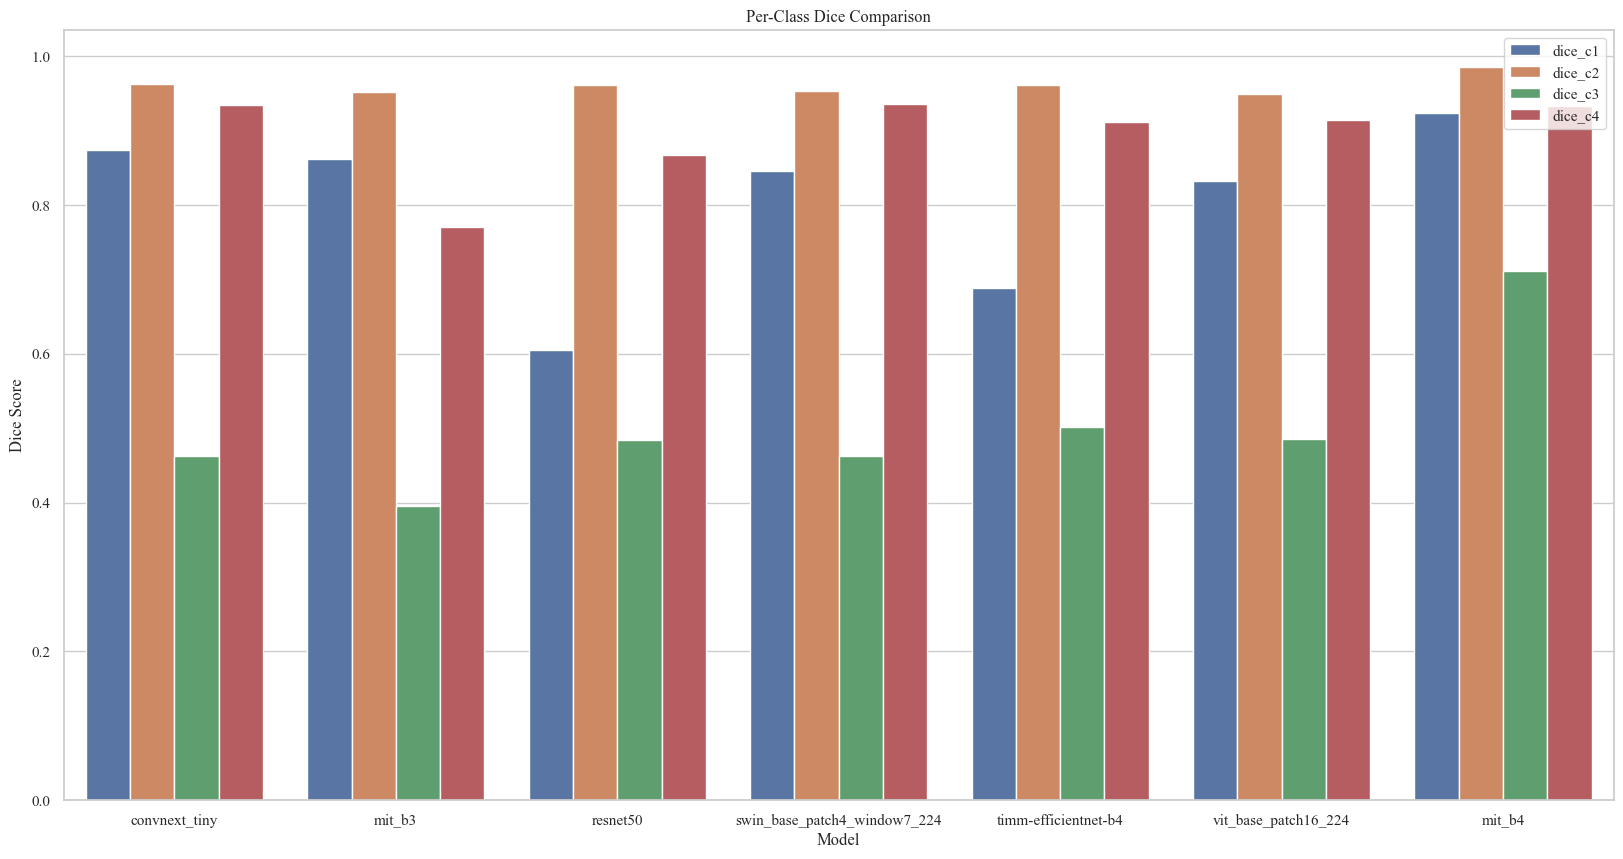

In [19]:
classes = ["dice_c1", "dice_c2", "dice_c3", "dice_c4"]

df_melt = df.melt(
    id_vars=["model_name"],
    value_vars=classes,
    var_name="Class",
    value_name="Dice"
)

plt.figure(figsize=(20,10))

sns.barplot(data=df_melt, x="model_name", y="Dice", hue="Class")
# plt.xticks(rotation=45)
plt.xlabel("Model")
plt.ylabel("Dice Score")

plt.legend(loc="upper right", bbox_to_anchor=(1, 1))
plt.title("Per-Class Dice Comparison")

plt.show()

### Heatmap of Model vs Class Performance

Helps to visualize which model is strong in which class, and also weakness patterns across models.

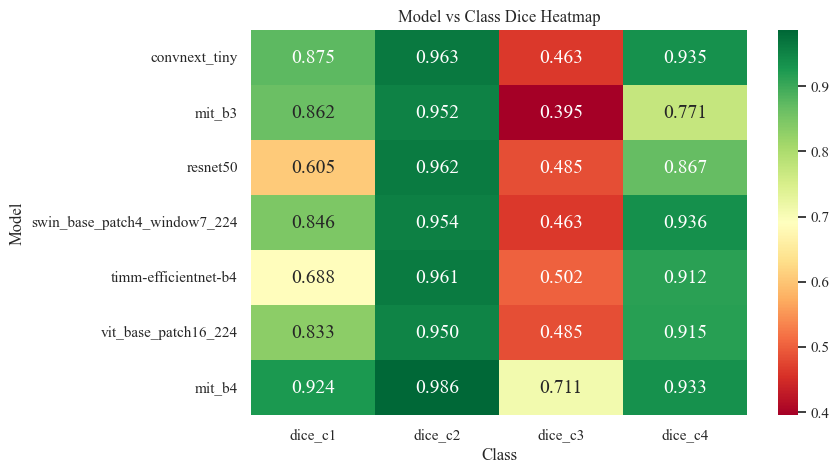

In [20]:
heatmap_data = df.set_index("model_name")[[
    "dice_c1", "dice_c2", "dice_c3", "dice_c4"
]]

plt.figure(figsize=(8,5))

sns.heatmap(heatmap_data, annot=True, cmap="RdYlGn", fmt=".3f")

plt.title("Model vs Class Dice Heatmap")
plt.xlabel("Class")
plt.ylabel("Model")
plt.show()

### Class Difficulty Analysis

Computing average Dice per class across all models to reveal which defect classes are easiest and hardest to segment.

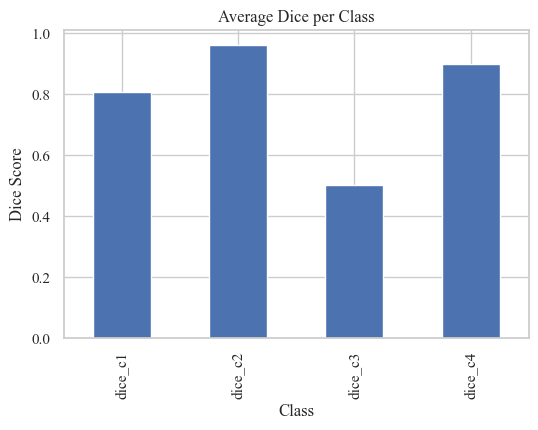

dice_c1    0.804664
dice_c2    0.961047
dice_c3    0.500501
dice_c4    0.895659
dtype: float64


In [21]:
class_means = df[["dice_c1", "dice_c2", "dice_c3", "dice_c4"]].mean()

plt.figure(figsize=(6,4))
class_means.plot(kind="bar")

plt.title("Average Dice per Class")
plt.xlabel("Class")
plt.ylabel("Dice Score")
plt.show()

print(class_means)

### Model Consistency Analysis

Measuring variance across class dice --> lower variance implies a more balanced model.

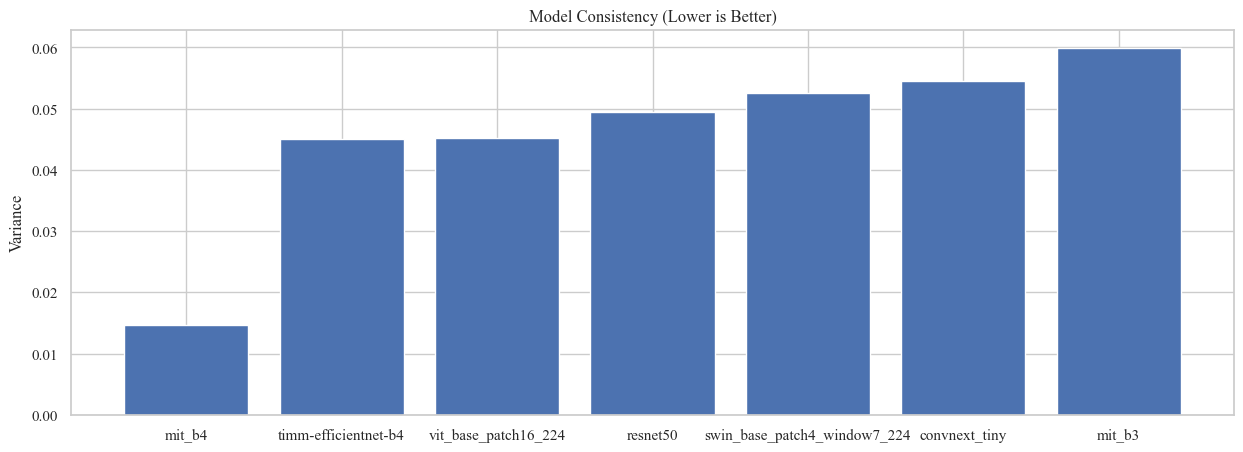

In [22]:
df["dice_variance"] = df[[
    "dice_c1", "dice_c2", "dice_c3", "dice_c4"
]].var(axis=1)

df_sorted_var = df.sort_values("dice_variance")

plt.figure(figsize=(15,5))
plt.bar(df_sorted_var["model_name"], df_sorted_var["dice_variance"])

# plt.xticks(rotation=45)
plt.title("Model Consistency (Lower is Better)")
plt.ylabel("Variance")

plt.show()

### Efficiency vs Performance

Comparing dice score with training epochs to identify efficient models.

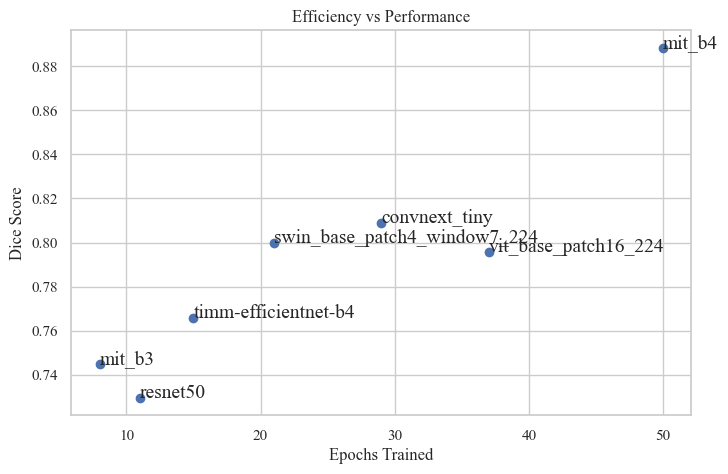

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(df["epochs_trained"], df["best_val_dice"])

for i, txt in enumerate(df["model_name"]):
    plt.annotate(txt, (df["epochs_trained"][i], df["best_val_dice"][i]))

plt.xlabel("Epochs Trained")
plt.ylabel("Dice Score")
plt.title("Efficiency vs Performance")

plt.show()

### Best Model Per Class

In [24]:
for c in ["dice_c1", "dice_c2", "dice_c3", "dice_c4"]:
    best_model = df.loc[df[c].idxmax()]
    print(f"{c.upper()} → {best_model['model_name']} ({best_model[c]:.4f})")

DICE_C1 → mit_b4 (0.9236)
DICE_C2 → mit_b4 (0.9858)
DICE_C3 → mit_b4 (0.7109)
DICE_C4 → swin_base_patch4_window7_224 (0.9363)


### Composite Ranking Score

Combining Overall Dice and Per-class Dice to create a balanced ranking metric.

In [25]:
df["composite_score"] = (
    df["best_val_dice"] +
    df["dice_c1"] +
    df["dice_c2"] +
    df["dice_c3"] +
    df["dice_c4"]
) / 5

df_final = df.sort_values("composite_score", ascending=False)

df_final[["model_name", "composite_score"]]

,model_name,composite_score
6,mit_b4,0.888382
0,convnext_tiny,0.808950
3,swin_base_patch4_window7_224,0.799870
5,vit_base_patch16_224,0.795552
4,timm-efficientnet-b4,0.765818
1,mit_b3,0.745096
2,resnet50,0.729608


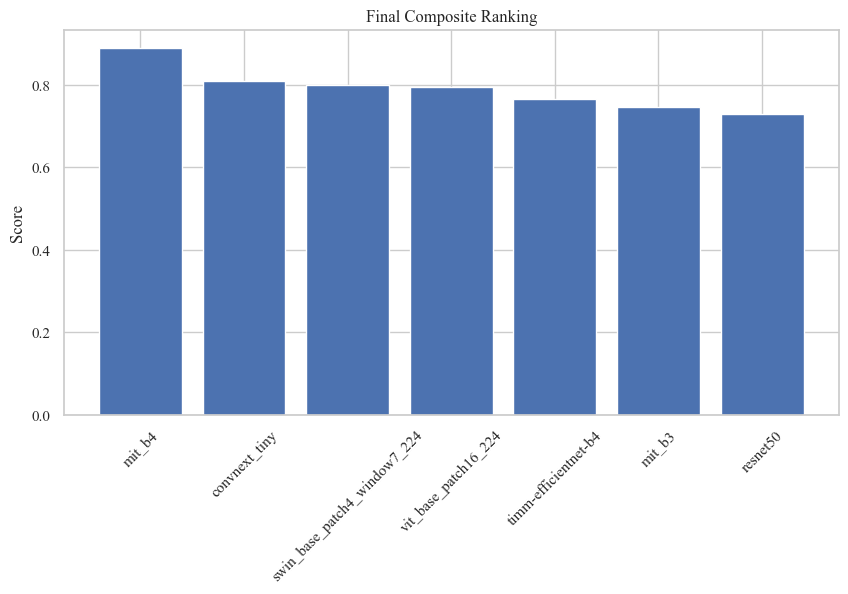

In [26]:
plt.figure(figsize=(10,5))

plt.bar(df_final["model_name"], df_final["composite_score"])
plt.xticks(rotation=45)

plt.title("Final Composite Ranking")
plt.ylabel("Score")

plt.show()

### Key Insights & Conclusions

1. Best Overall Model
    - Highest Dice score: **mit_b4**

2. Class-wise Observations
    - C1 & C2 are hardest (rare defects)
    - C3 & C4 easier and more stable

3. Model Behavior
    - Some models overfit common classes
    - Balanced models show lower variance

4. Efficiency
    - Some lightweight models achieve near-top performance with fewer epochs

5. Final Recommendation
    - Best model: **mit_b4**
    - Most balanced model: **mit_b4**